## DASYNet Grid-by-Grid Fine-tuning and Patch-Grid Analysis
### IDS 705 — Group 10

This notebook focuses on fine-tuning and analyzing a Convolutional Neural Network (CNN) called DASYNet for pneumonia detection, with a specific emphasis on its robustness to localized image corruptions.

Here's a breakdown of the key steps:

- Setup: Installs libraries, imports modules, sets up random seeds, and defines constants and file paths.
- DASYNet Architecture: Defines the custom DASYNet CNN model.
Data Preparation: Loads both clean and grid-corrupted (option 4) PneumoniaMNIST datasets, combines them, and creates PyTorch DataLoaders.
- Model Fine-tuning: Loads a pre-trained DASYNet model and fine-tunes it using the combined clean and corrupted datasets. The training and validation performance during fine-tuning are tracked.
Training Visualization: Plots the fine-tuning loss and accuracy curves.
- Validation Evaluation: Evaluates the grid fine-tuned model on the clean validation set and on validation images where specific corruptions (Brightness Contrast, JPEG, Downsampling, Gaussian Blur) are applied to individual 3x3 grid squares. The results are printed and saved to a CSV.
- Comparative Model Loading: Loads two DASYNet models for comparison: one that was fine-tuned on whole images (model_pretrained) and the newly fine-tuned model (model_finetuned) trained with grid-corrupted data.
- Attack Infrastructure: Defines various image corruption types and levels (L1, L2, L3) and helper functions for applying these attacks and evaluating model performance.
- Baseline Calculation: Calculates baseline performance metrics (accuracy, precision, recall, F1, AUROC) for both models on a clean test set.
- Patch-Grid Analysis: Conducts a detailed analysis where each of the 9 grid squares of the test images is individually subjected to various attacks (Gaussian Blur, Downsampling, JPEG, Brightness, Contrast, Gamma) at different severity levels (L1, L2, L3). This is performed for both models.
- FGSM Patch-Grid Analysis: Performs a similar grid-by-grid analysis specifically for the Fast Gradient Sign Method (FGSM) adversarial attack at the L3 severity level.
- Heatmap Visualization: Generates heatmaps to visually represent the accuracy drop in each 3x3 grid region for each attack type and level, comparing the two models.
- Flagging Report: Identifies and reports specific attack-level-position combinations where the model's accuracy drops significantly (greater than 5%), categorizing them as 'VULNERABLE'. This is done for both models and the results are saved to CSV files.
- Improvement Summary: Quantifies the improvement in robustness of the grid fine-tuned model compared to the whole-image fine-tuned model across all attack-level-position combinations, highlighting areas where grid fine-tuning was most beneficial.

In [1]:
# ── Step 1: Mount Drive and install ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install medmnist scikit-learn --quiet

import os
import io
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import medmnist
from medmnist import INFO, PneumoniaMNIST
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from PIL import Image

# Fix random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Libraries loaded!')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.6 MB/s eta 0:00:00
Device: cuda
Libraries loaded!


In [2]:
ckpt = torch.load('/content/drive/MyDrive/Clean_images_and_corrupted_images_(by grid)/dasynet_finetuned.pth', map_location='cpu')
torch.save(ckpt, '/content/drive/MyDrive/Clean_images_and_corrupted_images_(by grid)/dasynet_pneumonia.pth')
print('✅ Saved!')

# Verify
fpath = '/content/drive/MyDrive/Clean_images_and_corrupted_images_(by grid)/dasynet_pneumonia.pth'
if os.path.exists(fpath):
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f'✅ {size_mb:.1f} MB — confirmed saved')
else:
    print('❌ NOT FOUND')

✅ Saved!
✅ 0.4 MB — confirmed saved


In [3]:
# ── Step 2: Constants and paths ───────────────────────────────
SIZE            = 224
BATCH_SIZE      = 64
FINETUNE_EPOCHS = 5
FINETUNE_LR     = 1e-4
DATA_ROOT       = os.path.expanduser('~/.medmnist')

CORRUPTED_DIR = '/content/drive/MyDrive/Clean_images_and_corrupted_images_(by grid)/Corrupted_by_grid_images'
WEIGHTS_FILE  = '/content/drive/MyDrive/Clean_images_and_corrupted_images_(by grid)/dasynet_pneumonia.pth'
FT_WEIGHTS    = '/content/drive/MyDrive/Clean_images_and_corrupted_images_(by grid)/dasynet_finetuned_grid.pth'

print('Constants set ✓')

Constants set ✓


In [4]:
# ── Step 3: DASYNet architecture ──────────────────────────────
class DASYNET(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super(DASYNET, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d((3, 3))
        self.flatten     = nn.Flatten()
        self.classifier  = nn.Sequential(
            nn.Linear(64 * 3 * 3, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x)
        x = self.flatten(x)
        return self.classifier(x)

print('DASYNet defined ✓')

DASYNet defined ✓


In [5]:
# ── Step 4: Clean transform ───────────────────────────────────
clean_transform = transforms.Compose([
    transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
    transforms.Lambda(lambda img: img.convert('L')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
print('Clean transform defined ✓')

Clean transform defined ✓


In [6]:
# ── Step 5: Load clean train and val from MedMNIST ───────────
train_clean = PneumoniaMNIST(split='train', transform=clean_transform,
                              download=True, root=DATA_ROOT, size=SIZE)
val_clean   = PneumoniaMNIST(split='val',   transform=clean_transform,
                              download=True, root=DATA_ROOT, size=SIZE)

def load_all(dataset):
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    images, labels = next(iter(loader))
    return images, labels.squeeze().long()

clean_train_images, clean_train_labels = load_all(train_clean)
clean_val_images,   clean_val_labels   = load_all(val_clean)

print(f'Clean train: {clean_train_images.shape}')
print(f'Clean val:   {clean_val_images.shape}')

100%|██████████| 214M/214M [00:02<00:00, 78.0MB/s]


Clean train: torch.Size([4708, 1, 224, 224])
Clean val:   torch.Size([524, 1, 224, 224])


In [7]:
# ── Step 6: Load corrupted train and val ─────────────────────
print('Loading corrupted train set...')
train_data           = torch.load(os.path.join(CORRUPTED_DIR, 'train_corrupted_option4.pt'), weights_only=False)
corrupt_train_images = train_data['images']
corrupt_train_labels = train_data['labels'].squeeze().long()
del train_data
print(f'Corrupted train: {corrupt_train_images.shape}')

print('Loading corrupted val set...')
val_data           = torch.load(os.path.join(CORRUPTED_DIR, 'val_corrupted_option4.pt'), weights_only=False)
corrupt_val_images = val_data['images']
corrupt_val_labels = val_data['labels'].squeeze().long()
del val_data
print(f'Corrupted val: {corrupt_val_images.shape}')

Loading corrupted train set...
Corrupted train: torch.Size([18832, 1, 224, 224])
Loading corrupted val set...
Corrupted val: torch.Size([2096, 1, 224, 224])


In [8]:
# ── Step 7: Combine clean + corrupted ────────────────────────
combined_train_images = torch.cat([clean_train_images, corrupt_train_images], dim=0)
combined_train_labels = torch.cat([clean_train_labels, corrupt_train_labels], dim=0)

combined_val_images = torch.cat([clean_val_images, corrupt_val_images], dim=0)
combined_val_labels = torch.cat([clean_val_labels, corrupt_val_labels], dim=0)

print(f'Combined train: {combined_train_images.shape[0]:,} images')
print(f'  Clean:        {clean_train_images.shape[0]:,}')
print(f'  Corrupted:    {corrupt_train_images.shape[0]:,}')
print(f'Combined val:   {combined_val_images.shape[0]:,} images')
print(f'  Clean:        {clean_val_images.shape[0]:,}')
print(f'  Corrupted:    {corrupt_val_images.shape[0]:,}')

del clean_train_images, corrupt_train_images
del clean_val_images,   corrupt_val_images
torch.cuda.empty_cache()

Combined train: 23,540 images
  Clean:        4,708
  Corrupted:    18,832
Combined val:   2,620 images
  Clean:        524
  Corrupted:    2,096


In [9]:
# ── Step 8: Create DataLoaders ────────────────────────────────
train_dataset = TensorDataset(combined_train_images, combined_train_labels)
val_dataset   = TensorDataset(combined_val_images,   combined_val_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, pin_memory=True)

print(f'Train loader: {len(train_loader)} batches')
print(f'Val loader:   {len(val_loader)} batches')

Train loader: 368 batches
Val loader:   41 batches


In [10]:
# ── Step 9: Load pretrained weights and fine-tune ─────────────
model = DASYNET(in_channels=1, num_classes=2)
ckpt  = torch.load(WEIGHTS_FILE, map_location=device, weights_only=False)
model.load_state_dict(ckpt)
model.to(device)
model.eval()
print(f'DASYNet loaded — {sum(p.numel() for p in model.parameters()):,} parameters ✓')

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   []}

print(f'Fine-tuning for {FINETUNE_EPOCHS} epochs...\n')

for epoch in range(FINETUNE_EPOCHS):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        out  = model(imgs)
        loss = criterion(out, lbls)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += lbls.size(0)

    train_loss = run_loss / total
    train_acc  = 100. * correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            val_loss    += loss.item() * imgs.size(0)
            val_correct += out.argmax(1).eq(lbls).sum().item()
            val_total   += lbls.size(0)

    val_loss = val_loss / val_total
    val_acc  = 100. * val_correct / val_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    scheduler.step(val_loss)

    print(f'Epoch [{epoch+1:02d}/{FINETUNE_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%')

torch.save(model.state_dict(), FT_WEIGHTS)
print(f'\n✅ Fine-tuned weights saved → {FT_WEIGHTS}')

DASYNet loaded — 97,634 parameters ✓
Fine-tuning for 5 epochs...

Epoch [01/5]  Train Loss: 0.0510  Train Acc: 98.06%  |  Val Loss: 0.0953  Val Acc: 96.18%
Epoch [02/5]  Train Loss: 0.0398  Train Acc: 98.45%  |  Val Loss: 0.0618  Val Acc: 98.09%
Epoch [03/5]  Train Loss: 0.0364  Train Acc: 98.56%  |  Val Loss: 0.0549  Val Acc: 98.21%
Epoch [04/5]  Train Loss: 0.0338  Train Acc: 98.72%  |  Val Loss: 0.0671  Val Acc: 97.75%
Epoch [05/5]  Train Loss: 0.0280  Train Acc: 98.90%  |  Val Loss: 0.0669  Val Acc: 97.90%

✅ Fine-tuned weights saved → /content/drive/MyDrive/Clean_images_and_corrupted_images_(by grid)/dasynet_finetuned_grid.pth


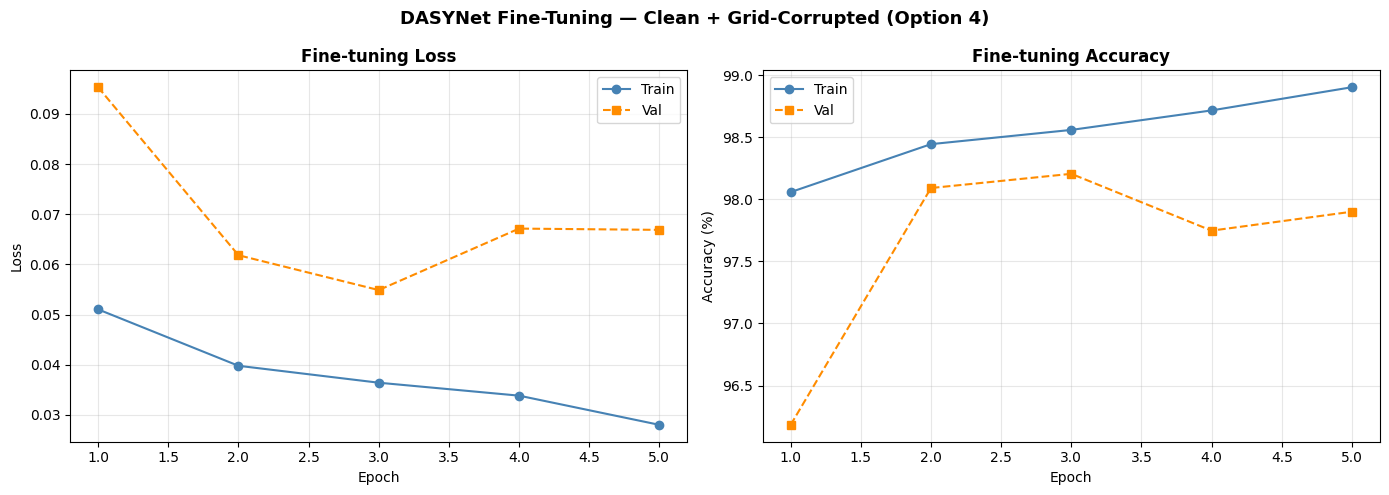

In [11]:
# ── Step 10: Training curves ──────────────────────────────────
epochs = range(1, FINETUNE_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], 'o-', color='steelblue', label='Train')
axes[0].plot(epochs, history['val_loss'],   's--', color='darkorange', label='Val')
axes[0].set_title('Fine-tuning Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'o-', color='steelblue', label='Train')
axes[1].plot(epochs, history['val_acc'],   's--', color='darkorange', label='Val')
axes[1].set_title('Fine-tuning Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('DASYNet Fine-Tuning — Clean + Grid-Corrupted (Option 4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dasynet_grid_finetune_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Step 11: Evaluate grid fine-tuned model on val set ───────
# Clean val + 4 attacks applied grid by grid at L3

def compute_metrics_simple(y_score, y_true, threshold=0.5):
    y_pred   = (y_score[:, 1] >= threshold).astype(int)
    y_true_f = y_true.flatten().astype(int)
    return {
        'accuracy' : accuracy_score(y_true_f, y_pred),
        'precision': precision_score(y_true_f, y_pred, zero_division=0),
        'recall'   : recall_score(y_true_f, y_pred, zero_division=0),
        'f1'       : f1_score(y_true_f, y_pred, zero_division=0),
        'auroc'    : roc_auc_score(y_true_f, y_score[:, 1]),
    }

def jpeg_compress_pil(img, quality):
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).copy()

def get_square_bounds_early(s, size=224):
    row, col = s // 3, s % 3
    step = size // 3
    y0   = row * step
    y1   = (row + 1) * step if row < 2 else size
    x0   = col * step
    x1   = (col + 1) * step if col < 2 else size
    return y0, y1, x0, x1

def evaluate_val_grid(model, clean_loader, atk_loader, attack_name, label):
    """Evaluate model with attack applied to each grid square separately"""
    clean_imgs_all, atk_imgs_all, all_labels = [], [], []
    for (c_imgs, lbls), (a_imgs, _) in zip(clean_loader, atk_loader):
        clean_imgs_all.append(c_imgs)
        atk_imgs_all.append(a_imgs)
        all_labels.append(lbls.numpy())

    clean_imgs_all = torch.cat(clean_imgs_all, dim=0)
    atk_imgs_all   = torch.cat(atk_imgs_all,   dim=0)
    y_true_v       = np.concatenate(all_labels)

    square_results = []
    for s in range(9):
        y0, y1, x0, x1 = get_square_bounds_early(s)
        all_scores = []
        model.eval()
        with torch.no_grad():
            for start in range(0, len(clean_imgs_all), BATCH_SIZE):
                c_batch = clean_imgs_all[start:start+BATCH_SIZE].to(device)
                a_batch = atk_imgs_all[start:start+BATCH_SIZE].to(device)
                mixed   = c_batch.clone()
                mixed[:, :, y0:y1, x0:x1] = a_batch[:, :, y0:y1, x0:x1]
                scores  = torch.softmax(model(mixed), dim=1)
                all_scores.append(scores.cpu().numpy())

        y_score_p = np.concatenate(all_scores)
        m = compute_metrics_simple(y_score_p, y_true_v)
        m['Split']  = f'{label} — Square {s}'
        square_results.append(m)

    return square_results

results = []

# 1. Clean val
val_clean_ds     = PneumoniaMNIST(split='val', transform=clean_transform,
                                   download=True, root=DATA_ROOT, size=SIZE)
val_clean_loader = DataLoader(val_clean_ds, batch_size=BATCH_SIZE, shuffle=False)

def evaluate_val_clean(loader, label):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(device))
            scores = torch.softmax(logits, dim=1)
            all_scores.append(scores.cpu().numpy())
            all_labels.append(lbls.numpy())
    y_score  = np.concatenate(all_scores)
    y_true_v = np.concatenate(all_labels)
    m = compute_metrics_simple(y_score, y_true_v)
    m['Split'] = label
    return m

results.append(evaluate_val_clean(val_clean_loader, 'Clean val'))

# 2. Each of your 4 attack types at L3 — applied grid by grid
attack_transforms = {
    'Brightness Contrast': transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('L')),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
        transforms.Lambda(lambda t: torch.clamp(
            torch.clamp(t - 0.3, -1, 1) * 0.4, -1, 1))
    ]),
    'JPEG': transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('L')),
        transforms.Lambda(lambda img: jpeg_compress_pil(img, 30)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    'Downsampling': transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('L')),
        transforms.Resize((max(1, int(SIZE * 0.3)), max(1, int(SIZE * 0.3))),
                          interpolation=Image.NEAREST),
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    'Gaussian Blur': transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('L')),
        transforms.GaussianBlur(kernel_size=11, sigma=2.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
}

for attack_name, atk_transform in attack_transforms.items():
    print(f'  Evaluating {attack_name} grid by grid...')
    atk_ds     = PneumoniaMNIST(split='val', transform=atk_transform,
                                 download=False, root=DATA_ROOT, size=SIZE)
    atk_loader = DataLoader(atk_ds, batch_size=BATCH_SIZE, shuffle=False)
    square_results = evaluate_val_grid(model, val_clean_loader, atk_loader,
                                       attack_name, attack_name)
    results.extend(square_results)

# Print results
df_val = pd.DataFrame(results).set_index('Split').round(4)
print('\n=== Grid Fine-tuned DASYNet — Val Results (Grid by Grid, L3) ===')
print(df_val.to_string())
df_val.to_csv('dasynet_val_evaluation.csv')
print('\nSaved: dasynet_val_evaluation.csv')

  Evaluating Brightness Contrast grid by grid...
  Evaluating JPEG grid by grid...
  Evaluating Downsampling grid by grid...
  Evaluating Gaussian Blur grid by grid...

=== Grid Fine-tuned DASYNet — Val Results (Grid by Grid, L3) ===
                                accuracy  precision  recall      f1   auroc
Split                                                                      
Clean val                         0.9828     0.9872  0.9897  0.9884  0.9973
Brightness Contrast — Square 0    0.9828     0.9847  0.9923  0.9885  0.9974
Brightness Contrast — Square 1    0.9771     0.9796  0.9897  0.9847  0.9959
Brightness Contrast — Square 2    0.9733     0.9771  0.9871  0.9821  0.9976
Brightness Contrast — Square 3    0.9809     0.9847  0.9897  0.9872  0.9968
Brightness Contrast — Square 4    0.9714     0.9795  0.9820  0.9807  0.9953
Brightness Contrast — Square 5    0.9790     0.9846  0.9871  0.9859  0.9962
Brightness Contrast — Square 6    0.9695     0.9674  0.9923  0.9797  0.9966
Bright

In [13]:
# ── Step 12: Load both models for comparison ──────────────────
model_pretrained = DASYNET(in_channels=1, num_classes=2)
ckpt_pre = torch.load(WEIGHTS_FILE, map_location=device, weights_only=False)
model_pretrained.load_state_dict(ckpt_pre)
model_pretrained.to(device)
model_pretrained.eval()
print('Whole-Image Fine-tuned DASYNet loaded ✓')

model_finetuned = DASYNET(in_channels=1, num_classes=2)
ckpt_ft = torch.load(FT_WEIGHTS, map_location=device, weights_only=False)
model_finetuned.load_state_dict(ckpt_ft)
model_finetuned.to(device)
model_finetuned.eval()
print('Grid Fine-tuned DASYNet loaded ✓')

Whole-Image Fine-tuned DASYNet loaded ✓
Grid Fine-tuned DASYNet loaded ✓


In [14]:
# ── Step 13: Attack infrastructure ───────────────────────────
LEVEL_INDICES = [0, 1, 2]
LEVEL_NAMES   = {0: 'L1', 1: 'L2', 2: 'L3'}

ATTACK_LEVELS = {
    'Gaussian Blur'      : [(3,0.5),(7,1.0),(11,2.0),(15,3.0),(21,5.0)],
    'Downsampling'       : [0.5, 0.4, 0.3, 0.2, 0.1],
    'JPEG'               : [75, 50, 30, 15, 5],
    'Brightness Dark'    : [-0.1,-0.2,-0.3,-0.4,-0.5],
    'Brightness Bright'  : [0.1, 0.2, 0.3, 0.4, 0.5],
    'Contrast Low'       : [0.8, 0.6, 0.4, 0.3, 0.2],
    'Contrast High'      : [1.2, 1.4, 1.6, 1.8, 2.0],
    'Gamma Overexposed'  : [0.9, 0.7, 0.5, 0.3, 0.1],
    'Gamma Underexposed' : [1.5, 2.0, 3.0, 4.0, 5.0],
}
ATTACK_NAMES_EVAL = list(ATTACK_LEVELS.keys())

RECALL_DANGER_THRESHOLD = 0.90
ROBUST_THRESHOLD        = 0.02
CONCERNING_THRESHOLD    = 0.05

square_labels = [
    'Top-Left',   'Top-Center',  'Top-Right',
    'Mid-Left',   'Center',      'Mid-Right',
    'Bot-Left',   'Bot-Center',  'Bot-Right'
]

def apply_gamma(t, gamma):
    t_01    = (t + 1) / 2
    t_gamma = torch.pow(t_01.clamp(min=1e-8), gamma)
    return (t_gamma * 2 - 1).clamp(-1, 1)

def make_single_transform(attack_name, level_idx):
    param     = ATTACK_LEVELS[attack_name][level_idx]
    pil_steps = [
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('L')),
    ]
    tensor_steps = []
    if attack_name == 'Gaussian Blur':
        ks, sig = param
        pil_steps.append(transforms.GaussianBlur(kernel_size=ks, sigma=sig))
    elif attack_name == 'Downsampling':
        small = max(1, int(SIZE * param))
        pil_steps.append(transforms.Resize((small, small), interpolation=Image.NEAREST))
        pil_steps.append(transforms.Resize((SIZE, SIZE),   interpolation=Image.NEAREST))
    elif attack_name == 'JPEG':
        pil_steps.append(transforms.Lambda(lambda img, q=param: jpeg_compress_pil(img, q)))
    elif attack_name in ('Brightness Dark', 'Brightness Bright'):
        tensor_steps.append(transforms.Lambda(lambda t, d=param: torch.clamp(t + d, -1.0, 1.0)))
    elif attack_name in ('Contrast Low', 'Contrast High'):
        tensor_steps.append(transforms.Lambda(lambda t, a=param: torch.clamp(t * a, -1.0, 1.0)))
    elif attack_name in ('Gamma Overexposed', 'Gamma Underexposed'):
        tensor_steps.append(transforms.Lambda(lambda t, g=param: apply_gamma(t, g)))
    return transforms.Compose(
        pil_steps +
        [transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])] +
        tensor_steps
    )

def get_square_bounds(s, size=SIZE):
    row, col = s // 3, s % 3
    step = size // 3
    y0   = row * step
    y1   = (row + 1) * step if row < 2 else size
    x0   = col * step
    x1   = (col + 1) * step if col < 2 else size
    return y0, y1, x0, x1

def verdict(acc_drop):
    if acc_drop < ROBUST_THRESHOLD:
        return 'ROBUST'
    elif acc_drop < CONCERNING_THRESHOLD:
        return 'CONCERNING'
    else:
        return 'VULNERABLE'

print('Attack infrastructure ready ✓')

Attack infrastructure ready ✓


In [15]:
# ── Step 14: Load clean val set for patch analysis ────────────
val_dataset  = PneumoniaMNIST(split='val', transform=clean_transform,
                               download=True, root=DATA_ROOT, size=SIZE)
clean_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_labels = []
for _, labels in clean_loader:
    all_labels.append(labels.numpy())
y_true = np.concatenate(all_labels)

print(f'Val set loaded: {len(val_dataset)} images ✓')

Val set loaded: 524 images ✓


In [16]:
# ── Step 15: Clean baselines for both models ──────────────────
def get_baseline(model, loader):
    model.eval()
    all_scores = []
    with torch.no_grad():
        for imgs, _ in loader:
            logits = model(imgs.to(device))
            scores = torch.softmax(logits, dim=1)
            all_scores.append(scores.cpu().numpy())
    return np.concatenate(all_scores)

y_score_pre  = get_baseline(model_pretrained, clean_loader)
y_score_ft   = get_baseline(model_finetuned,  clean_loader)
baseline_pre = compute_metrics_simple(y_score_pre, y_true)
baseline_ft  = compute_metrics_simple(y_score_ft,  y_true)

print('\n=== Clean Baseline — Whole-Image Fine-tuned DASYNet ===')
for k, v in baseline_pre.items():
    print(f'  {k:12s}: {v:.4f}')

print('\n=== Clean Baseline — Grid Fine-tuned DASYNet ===')
for k, v in baseline_ft.items():
    print(f'  {k:12s}: {v:.4f}')


=== Clean Baseline — Whole-Image Fine-tuned DASYNet ===
  accuracy    : 0.9790
  precision   : 0.9896
  recall      : 0.9820
  f1          : 0.9858
  auroc       : 0.9974

=== Clean Baseline — Grid Fine-tuned DASYNet ===
  accuracy    : 0.9828
  precision   : 0.9872
  recall      : 0.9897
  f1          : 0.9884
  auroc       : 0.9973


In [18]:
# ── Step 14b: Load clean test set ─────────────────────────────
test_dataset = PneumoniaMNIST(split='test', transform=clean_transform,
                               download=True, root=DATA_ROOT, size=SIZE)
clean_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_labels = []
for _, labels in clean_loader:
    all_labels.append(labels.numpy())
y_true = np.concatenate(all_labels)

print(f'Test set loaded: {len(test_dataset)} images ✓')

Test set loaded: 624 images ✓


In [19]:
def get_baseline(model, loader):
    model.eval()
    all_scores = []
    with torch.no_grad():
        for imgs, _ in loader:
            logits = model(imgs.to(device))
            scores = torch.softmax(logits, dim=1)
            all_scores.append(scores.cpu().numpy())
    return np.concatenate(all_scores)

y_score_pre  = get_baseline(model_pretrained, clean_loader)
y_score_ft   = get_baseline(model_finetuned,  clean_loader)
baseline_pre = compute_metrics_simple(y_score_pre, y_true)
baseline_ft  = compute_metrics_simple(y_score_ft,  y_true)

print('\n=== Clean Baseline — Whole-Image Fine-tuned DASYNet ===')
for k, v in baseline_pre.items():
    print(f'  {k:12s}: {v:.4f}')

print('\n=== Clean Baseline — Grid Fine-tuned DASYNet ===')
for k, v in baseline_ft.items():
    print(f'  {k:12s}: {v:.4f}')


=== Clean Baseline — Whole-Image Fine-tuned DASYNet ===
  accuracy    : 0.8974
  precision   : 0.8671
  recall      : 0.9872
  f1          : 0.9233
  auroc       : 0.9669

=== Clean Baseline — Grid Fine-tuned DASYNet ===
  accuracy    : 0.8846
  precision   : 0.8472
  recall      : 0.9949
  f1          : 0.9151
  auroc       : 0.9702


In [20]:
# ── Step 16: Patch-grid analysis — L1, L2, L3 ────────────────
def run_patch_analysis(model, baseline, model_name):
    print(f'\nRunning patch-grid analysis — {model_name}...')
    patch_results = {
        level_idx: {name: {} for name in ATTACK_NAMES_EVAL}
        for level_idx in LEVEL_INDICES
    }

    for level_idx in LEVEL_INDICES:
        print(f'\n  === Level {level_idx + 1} ===')
        for attack_name in ATTACK_NAMES_EVAL:
            print(f'    {attack_name}...')
            atk_tfm     = make_single_transform(attack_name, level_idx)
            atk_dataset = PneumoniaMNIST(split='test', transform=atk_tfm,
                                          download=False, root=DATA_ROOT, size=SIZE)
            atk_loader  = DataLoader(atk_dataset, batch_size=BATCH_SIZE, shuffle=False)

            clean_imgs_all, atk_imgs_all = [], []
            for (c_imgs, _), (a_imgs, _) in zip(clean_loader, atk_loader):
                clean_imgs_all.append(c_imgs)
                atk_imgs_all.append(a_imgs)
            clean_imgs_all = torch.cat(clean_imgs_all, dim=0)
            atk_imgs_all   = torch.cat(atk_imgs_all,   dim=0)

            for s in range(9):
                y0, y1, x0, x1 = get_square_bounds(s)
                all_scores = []
                model.eval()
                with torch.no_grad():
                    for start in range(0, len(clean_imgs_all), BATCH_SIZE):
                        c_batch = clean_imgs_all[start:start+BATCH_SIZE].to(device)
                        a_batch = atk_imgs_all[start:start+BATCH_SIZE].to(device)
                        mixed   = c_batch.clone()
                        mixed[:, :, y0:y1, x0:x1] = a_batch[:, :, y0:y1, x0:x1]
                        scores  = torch.softmax(model(mixed), dim=1)
                        all_scores.append(scores.cpu().numpy())

                y_score_p = np.concatenate(all_scores)
                patch_results[level_idx][attack_name][s] = \
                    compute_metrics_simple(y_score_p, y_true)

            print(f'      ✓')

    return patch_results

patch_results_pre = run_patch_analysis(model_pretrained, baseline_pre, 'Whole-Image Fine-tuned DASYNet')
patch_results_ft  = run_patch_analysis(model_finetuned,  baseline_ft,  'Grid Fine-tuned DASYNet')
print('\n✅ Patch-grid analysis complete for L1, L2, L3!')


Running patch-grid analysis — Whole-Image Fine-tuned DASYNet...

  === Level 1 ===
    Gaussian Blur...
      ✓
    Downsampling...
      ✓
    JPEG...
      ✓
    Brightness Dark...
      ✓
    Brightness Bright...
      ✓
    Contrast Low...
      ✓
    Contrast High...
      ✓
    Gamma Overexposed...
      ✓
    Gamma Underexposed...
      ✓

  === Level 2 ===
    Gaussian Blur...
      ✓
    Downsampling...
      ✓
    JPEG...
      ✓
    Brightness Dark...
      ✓
    Brightness Bright...
      ✓
    Contrast Low...
      ✓
    Contrast High...
      ✓
    Gamma Overexposed...
      ✓
    Gamma Underexposed...
      ✓

  === Level 3 ===
    Gaussian Blur...
      ✓
    Downsampling...
      ✓
    JPEG...
      ✓
    Brightness Dark...
      ✓
    Brightness Bright...
      ✓
    Contrast Low...
      ✓
    Contrast High...
      ✓
    Gamma Overexposed...
      ✓
    Gamma Underexposed...
      ✓

Running patch-grid analysis — Grid Fine-tuned DASYNet...

  === Level 1 ===
    Ga

In [21]:
# ── Step 16b: FGSM patch-grid analysis — L3 only ─────────────
FGSM_EPSILON   = 0.01
FGSM_LEVEL_IDX = 2

def run_fgsm_patch_analysis(model, baseline, model_name, patch_results):
    print(f'\nRunning FGSM patch analysis — {model_name}...')
    criterion_fgsm = nn.CrossEntropyLoss()

    fgsm_imgs = []
    model.eval()
    for imgs, labels in clean_loader:
        imgs_req = imgs.to(device).requires_grad_(True)
        labels_t = labels.squeeze().long().to(device)
        logits   = model(imgs_req)
        loss     = criterion_fgsm(logits, labels_t)
        model.zero_grad()
        loss.backward()
        perturbed = imgs_req + FGSM_EPSILON * imgs_req.grad.sign()
        perturbed = torch.clamp(perturbed, -1.0, 1.0).detach().cpu()
        fgsm_imgs.append(perturbed)
    fgsm_imgs = torch.cat(fgsm_imgs, dim=0)
    print(f'  FGSM images pre-computed: {fgsm_imgs.shape} ✓')

    clean_imgs_all = []
    for imgs, _ in clean_loader:
        clean_imgs_all.append(imgs)
    clean_imgs_all = torch.cat(clean_imgs_all, dim=0)

    if 'FGSM' not in patch_results[FGSM_LEVEL_IDX]:
        patch_results[FGSM_LEVEL_IDX]['FGSM'] = {}

    for s in range(9):
        y0, y1, x0, x1 = get_square_bounds(s)
        all_scores = []
        model.eval()
        with torch.no_grad():
            for start in range(0, len(clean_imgs_all), BATCH_SIZE):
                c_batch = clean_imgs_all[start:start+BATCH_SIZE].to(device)
                a_batch = fgsm_imgs[start:start+BATCH_SIZE].to(device)
                mixed   = c_batch.clone()
                mixed[:, :, y0:y1, x0:x1] = a_batch[:, :, y0:y1, x0:x1]
                scores  = torch.softmax(model(mixed), dim=1)
                all_scores.append(scores.cpu().numpy())

        y_score_p = np.concatenate(all_scores)
        patch_results[FGSM_LEVEL_IDX]['FGSM'][s] = \
            compute_metrics_simple(y_score_p, y_true)
        print(f'    Square {s} ✓')

    print(f'  ✅ FGSM complete for {model_name}')
    return patch_results

patch_results_pre = run_fgsm_patch_analysis(
    model_pretrained, baseline_pre, 'Whole-Image Fine-tuned DASYNet', patch_results_pre)
patch_results_ft  = run_fgsm_patch_analysis(
    model_finetuned,  baseline_ft,  'Grid Fine-tuned DASYNet', patch_results_ft)
print('\n✅ FGSM patch analysis complete!')


Running FGSM patch analysis — Whole-Image Fine-tuned DASYNet...
  FGSM images pre-computed: torch.Size([624, 1, 224, 224]) ✓
    Square 0 ✓
    Square 1 ✓
    Square 2 ✓
    Square 3 ✓
    Square 4 ✓
    Square 5 ✓
    Square 6 ✓
    Square 7 ✓
    Square 8 ✓
  ✅ FGSM complete for Whole-Image Fine-tuned DASYNet

Running FGSM patch analysis — Grid Fine-tuned DASYNet...
  FGSM images pre-computed: torch.Size([624, 1, 224, 224]) ✓
    Square 0 ✓
    Square 1 ✓
    Square 2 ✓
    Square 3 ✓
    Square 4 ✓
    Square 5 ✓
    Square 6 ✓
    Square 7 ✓
    Square 8 ✓
  ✅ FGSM complete for Grid Fine-tuned DASYNet

✅ FGSM patch analysis complete!


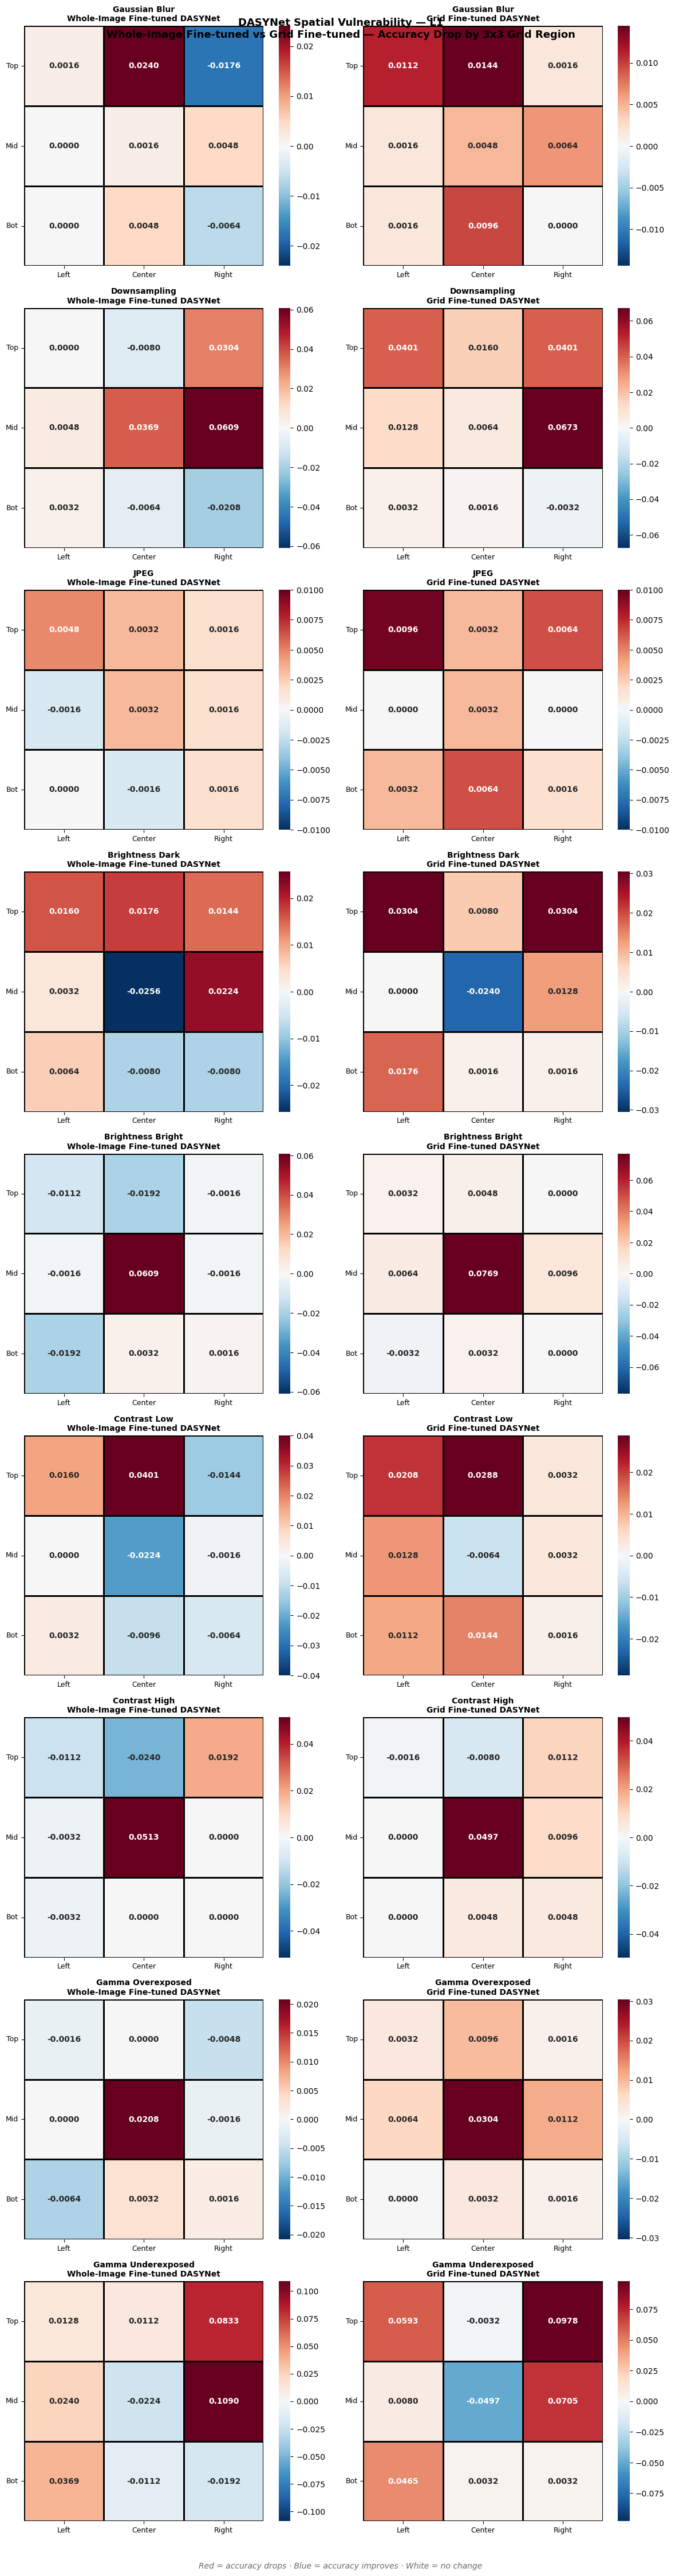

✅ Heatmaps saved for L1


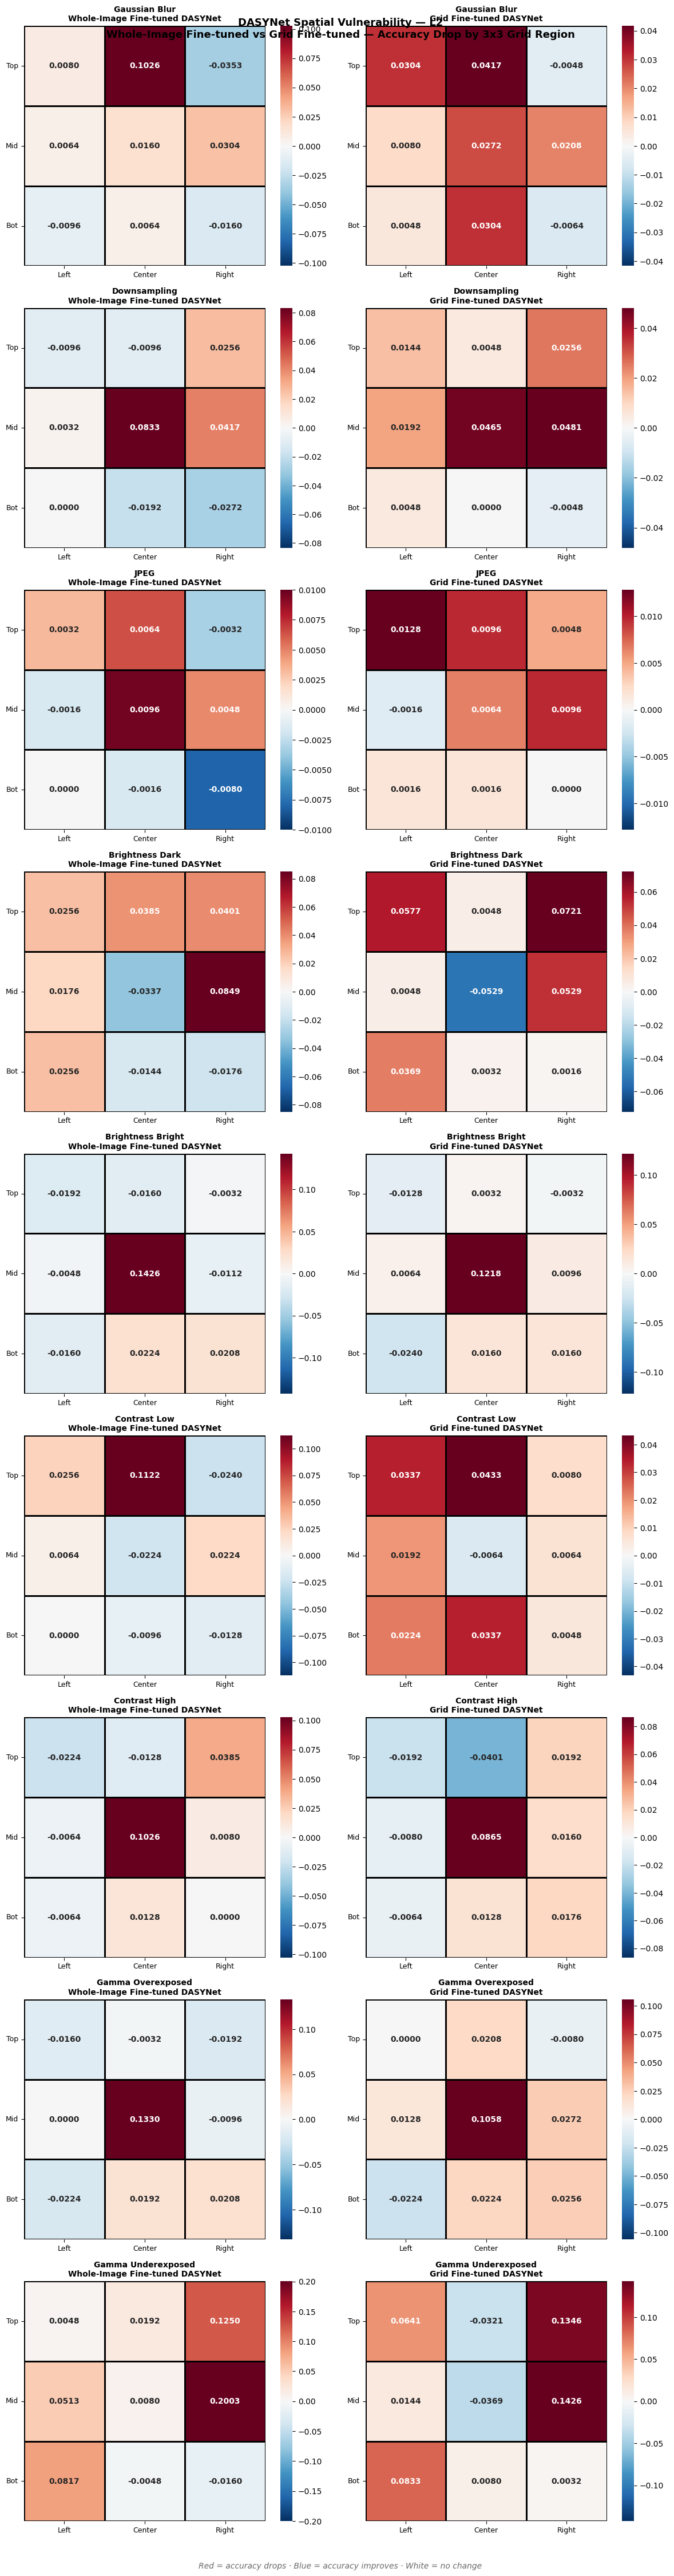

✅ Heatmaps saved for L2


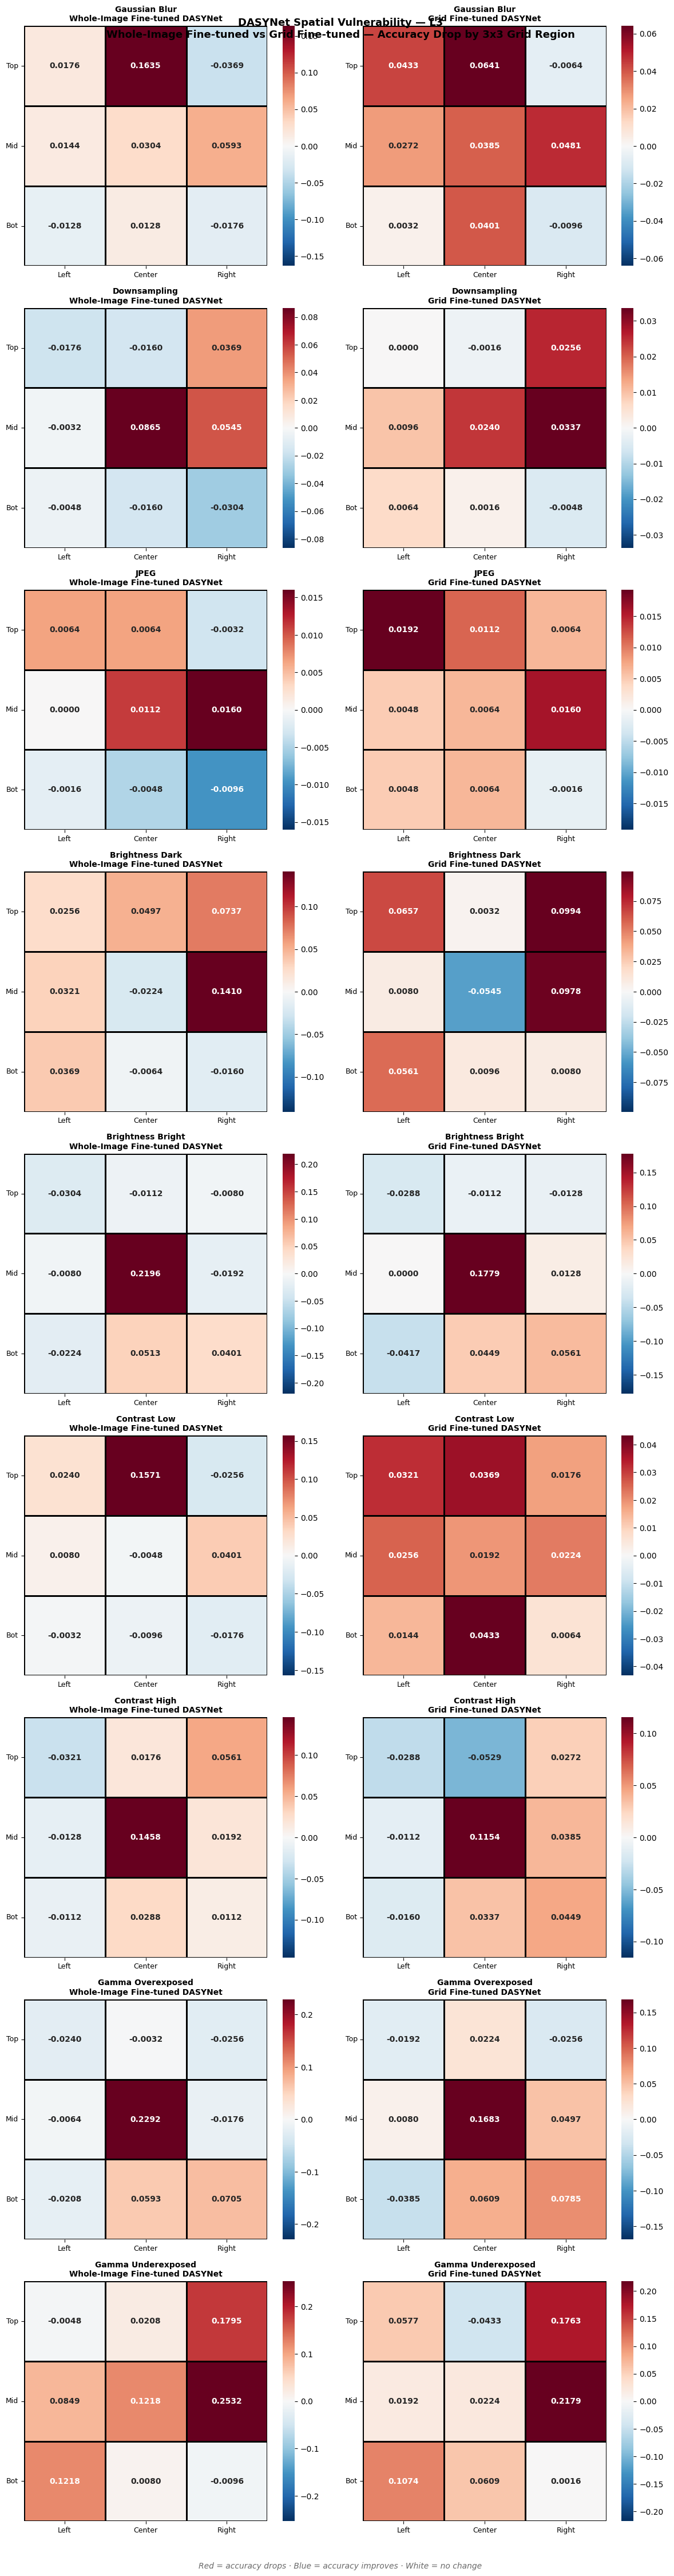

✅ Heatmaps saved for L3


In [22]:
# ── Step 17: Heatmaps — L1, L2, L3 ──────────────────────────
for level_idx in LEVEL_INDICES:
    level_name = LEVEL_NAMES[level_idx]
    fig, axes  = plt.subplots(len(ATTACK_NAMES_EVAL), 2,
                               figsize=(12, 5 * len(ATTACK_NAMES_EVAL)))

    for idx, attack_name in enumerate(ATTACK_NAMES_EVAL):
        for col, (results, baseline, title) in enumerate([
            (patch_results_pre, baseline_pre, 'Whole-Image Fine-tuned DASYNet'),
            (patch_results_ft,  baseline_ft,  'Grid Fine-tuned DASYNet'),
        ]):
            ax = axes[idx, col]
            grid_drop = np.zeros((3, 3))
            for s in range(9):
                row_s, col_s = s // 3, s % 3
                acc_drop = baseline['accuracy'] - \
                           results[level_idx][attack_name][s]['accuracy']
                grid_drop[row_s, col_s] = acc_drop

            vmax = max(abs(grid_drop.max()), abs(grid_drop.min()), 0.01)
            sns.heatmap(grid_drop, annot=True, fmt='.4f', ax=ax,
                        cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                        linewidths=1, linecolor='black', cbar=True,
                        annot_kws={'fontsize': 10, 'fontweight': 'bold'})
            ax.set_title(f'{attack_name}\n{title}', fontsize=10, fontweight='bold')
            ax.set_xticklabels(['Left', 'Center', 'Right'], fontsize=9)
            ax.set_yticklabels(['Top', 'Mid', 'Bot'], fontsize=9, rotation=0)

    fig.suptitle(f'DASYNet Spatial Vulnerability — {level_name}\n'
                 f'Whole-Image Fine-tuned vs Grid Fine-tuned — Accuracy Drop by 3x3 Grid Region',
                 fontsize=13, fontweight='bold')
    fig.text(0.5, -0.01,
             'Red = accuracy drops · Blue = accuracy improves · White = no change',
             ha='center', fontsize=10, style='italic', color='dimgray')
    plt.tight_layout()
    plt.savefig(f'dasynet_heatmaps_{level_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Heatmaps saved for {level_name}')

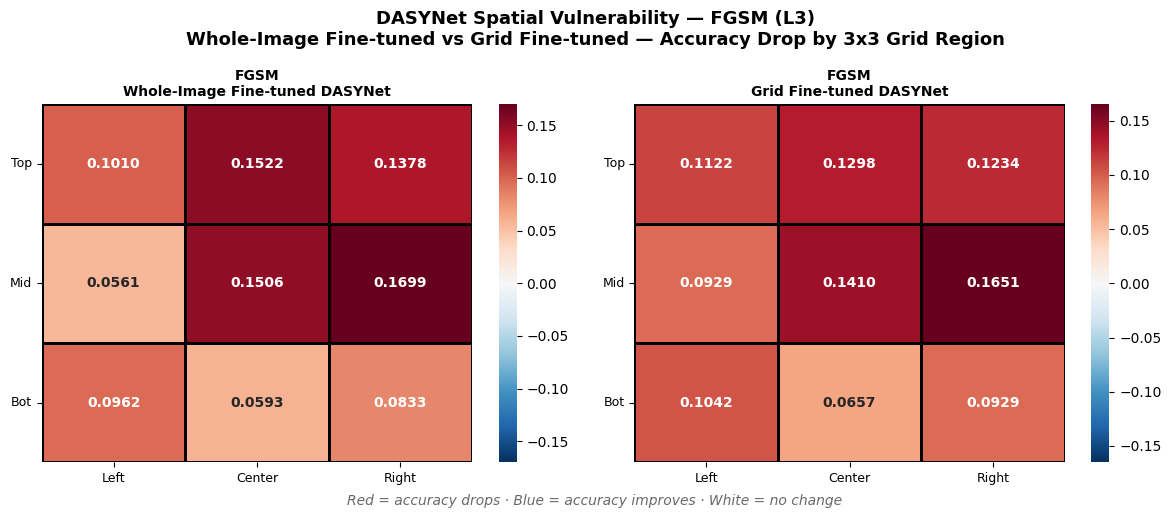

✅ FGSM heatmap saved


In [23]:
# ── Step 17b: FGSM heatmap — L3 only ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col, (results, baseline, title) in enumerate([
    (patch_results_pre, baseline_pre, 'Whole-Image Fine-tuned DASYNet'),
    (patch_results_ft,  baseline_ft,  'Grid Fine-tuned DASYNet'),
]):
    ax = axes[col]
    grid_drop = np.zeros((3, 3))
    for s in range(9):
        row_s, col_s = s // 3, s % 3
        acc_drop = baseline['accuracy'] - \
                   results[FGSM_LEVEL_IDX]['FGSM'][s]['accuracy']
        grid_drop[row_s, col_s] = acc_drop

    vmax = max(abs(grid_drop.max()), abs(grid_drop.min()), 0.01)
    sns.heatmap(grid_drop, annot=True, fmt='.4f', ax=ax,
                cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                linewidths=1, linecolor='black', cbar=True,
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_title(f'FGSM\n{title}', fontsize=10, fontweight='bold')
    ax.set_xticklabels(['Left', 'Center', 'Right'], fontsize=9)
    ax.set_yticklabels(['Top', 'Mid', 'Bot'], fontsize=9, rotation=0)

fig.suptitle('DASYNet Spatial Vulnerability — FGSM (L3)\n'
             'Whole-Image Fine-tuned vs Grid Fine-tuned — Accuracy Drop by 3x3 Grid Region',
             fontsize=13, fontweight='bold')
fig.text(0.5, -0.01,
         'Red = accuracy drops · Blue = accuracy improves · White = no change',
         ha='center', fontsize=10, style='italic', color='dimgray')
plt.tight_layout()
plt.savefig('dasynet_heatmaps_FGSM_L3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ FGSM heatmap saved')

In [24]:
# ── Step 18: Flagging report — L1, L2, L3 + FGSM ────────────
for model_name, results, baseline in [
    ('Whole-Image Fine-tuned DASYNet', patch_results_pre, baseline_pre),
    ('Grid Fine-tuned DASYNet',        patch_results_ft,  baseline_ft),
]:
    print(f'\n{"="*70}')
    print(f'⚠️  FLAGGING REPORT — {model_name} — Acc Drop > 5%')
    print(f'{"="*70}')

    flag_rows = []

    for level_idx in LEVEL_INDICES:
        for attack_name in ATTACK_NAMES_EVAL:
            for s in range(9):
                m        = results[level_idx][attack_name][s]
                acc_drop = baseline['accuracy'] - m['accuracy']
                if acc_drop > 0.05:
                    flag_rows.append({
                        'Level'   : LEVEL_NAMES[level_idx],
                        'Attack'  : attack_name,
                        'Position': square_labels[s],
                        'Acc Drop': round(acc_drop, 4),
                        'Accuracy': round(m['accuracy'], 4),
                        'Recall'  : round(m['recall'], 4),
                        'Verdict' : verdict(acc_drop),
                    })

    for s in range(9):
        m        = results[FGSM_LEVEL_IDX]['FGSM'][s]
        acc_drop = baseline['accuracy'] - m['accuracy']
        if acc_drop > 0.05:
            flag_rows.append({
                'Level'   : 'L3',
                'Attack'  : 'FGSM',
                'Position': square_labels[s],
                'Acc Drop': round(acc_drop, 4),
                'Accuracy': round(m['accuracy'], 4),
                'Recall'  : round(m['recall'], 4),
                'Verdict' : verdict(acc_drop),
            })

    if flag_rows:
        df_flags = pd.DataFrame(flag_rows).sort_values('Acc Drop', ascending=False)
        df_flags = df_flags.set_index(['Level', 'Attack', 'Position'])
        csv_name = f'dasynet_{"grid" if "Grid" in model_name else "wholeimage"}_flags_L1L2L3_FGSM.csv'
        df_flags.to_csv(csv_name)
        print(df_flags.to_string())
        print(f'\nTotal flagged: {len(flag_rows)}')
        print(f'Saved: {csv_name}')
        pos_counts = Counter([r['Position'] for r in flag_rows])
        print('\nMost vulnerable positions:')
        for pos, cnt in pos_counts.most_common():
            print(f'  {pos:<15s}: {cnt} flags')
    else:
        print('  No combinations exceeded 5% accuracy drop.')


⚠️  FLAGGING REPORT — Whole-Image Fine-tuned DASYNet — Acc Drop > 5%
                                     Acc Drop  Accuracy  Recall     Verdict
Level Attack             Position                                          
L3    Gamma Underexposed Mid-Right     0.2532    0.6442  1.0000  VULNERABLE
      Gamma Overexposed  Center        0.2292    0.6683  1.0000  VULNERABLE
      Brightness Bright  Center        0.2196    0.6779  1.0000  VULNERABLE
L2    Gamma Underexposed Mid-Right     0.2003    0.6971  1.0000  VULNERABLE
L3    Gamma Underexposed Top-Right     0.1795    0.7179  1.0000  VULNERABLE
      FGSM               Mid-Right     0.1699    0.7276  0.9128  VULNERABLE
      Gaussian Blur      Top-Center    0.1635    0.7340  1.0000  VULNERABLE
      Contrast Low       Top-Center    0.1571    0.7404  1.0000  VULNERABLE
      FGSM               Top-Center    0.1522    0.7452  0.9077  VULNERABLE
                         Center        0.1506    0.7468  0.9256  VULNERABLE
      Contrast Hig

In [25]:
# ── Step 19: Improvement summary — L1, L2, L3 + FGSM ────────
print('\n=== Summary: Whole-Image Fine-tuned vs Grid Fine-tuned DASYNet ===\n')

rows = []

for level_idx in LEVEL_INDICES:
    for attack_name in ATTACK_NAMES_EVAL:
        for s in range(9):
            pre_acc     = patch_results_pre[level_idx][attack_name][s]['accuracy']
            ft_acc      = patch_results_ft[level_idx][attack_name][s]['accuracy']
            pre_drop    = baseline_pre['accuracy'] - pre_acc
            ft_drop     = baseline_ft['accuracy']  - ft_acc
            improvement = pre_drop - ft_drop
            rows.append({
                'Level'              : LEVEL_NAMES[level_idx],
                'Attack'             : attack_name,
                'Position'           : square_labels[s],
                'Whole-Image FT Drop': round(pre_drop, 4),
                'Grid FT Drop'       : round(ft_drop, 4),
                'Improvement'        : round(improvement, 4),
            })

for s in range(9):
    pre_acc     = patch_results_pre[FGSM_LEVEL_IDX]['FGSM'][s]['accuracy']
    ft_acc      = patch_results_ft[FGSM_LEVEL_IDX]['FGSM'][s]['accuracy']
    pre_drop    = baseline_pre['accuracy'] - pre_acc
    ft_drop     = baseline_ft['accuracy']  - ft_acc
    improvement = pre_drop - ft_drop
    rows.append({
        'Level'              : 'L3',
        'Attack'             : 'FGSM',
        'Position'           : square_labels[s],
        'Whole-Image FT Drop': round(pre_drop, 4),
        'Grid FT Drop'       : round(ft_drop, 4),
        'Improvement'        : round(improvement, 4),
    })

df_summary = pd.DataFrame(rows).sort_values('Improvement', ascending=False)
df_summary.to_csv('dasynet_grid_improvement_summary_L1L2L3_FGSM.csv', index=False)
print(df_summary.head(10).to_string(index=False))
print(f'\nTop improved: {df_summary.iloc[0]["Level"]} — '
      f'{df_summary.iloc[0]["Attack"]} — {df_summary.iloc[0]["Position"]}')
print('Saved: dasynet_grid_improvement_summary_L1L2L3_FGSM.csv')


=== Summary: Whole-Image Fine-tuned vs Grid Fine-tuned DASYNet ===

Level             Attack   Position  Whole-Image FT Drop  Grid FT Drop  Improvement
   L3       Contrast Low Top-Center               0.1571        0.0369       0.1202
   L3      Gaussian Blur Top-Center               0.1635        0.0641       0.0994
   L3 Gamma Underexposed     Center               0.1218        0.0224       0.0994
   L3      Contrast High Top-Center               0.0176       -0.0529       0.0705
   L2       Contrast Low Top-Center               0.1122        0.0433       0.0689
   L3 Gamma Underexposed   Mid-Left               0.0849        0.0192       0.0657
   L3 Gamma Underexposed Top-Center               0.0208       -0.0433       0.0641
   L3       Downsampling     Center               0.0865        0.0240       0.0625
   L2      Gaussian Blur Top-Center               0.1026        0.0417       0.0609
   L3  Gamma Overexposed     Center               0.2292        0.1683       0.0609

Top im